# Réseaux de neurones multicouches (MLP) avec Keras et scikit-learn

**Module :** Machine Learning 2 — ECE Paris, 2025/2026  
**Auteur :** Édouard Menut

Objectif : entraîner un réseau de neurones *feed-forward* sur le jeu **Digits** (1 797 images de chiffres manuscrits en 8×8 pixels, 10 classes) et étudier l'effet des principaux choix d'entraînement :

1. Préparation des données (split, standardisation, one-hot)
2. Premier modèle Keras et courbes d'apprentissage
3. Impact du taux d'apprentissage et de l'optimiseur (SGD vs Adam)
4. Impact de l'initialisation des poids
5. Callbacks : EarlyStopping, ModelCheckpoint, TensorBoard
6. Comparaison avec `MLPClassifier` de scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import optimizers, initializers

np.random.seed(42)
tf.random.set_seed(42)

## 1. Préparation des données

Images : (1797, 8, 8) | vecteurs : (1797, 64)


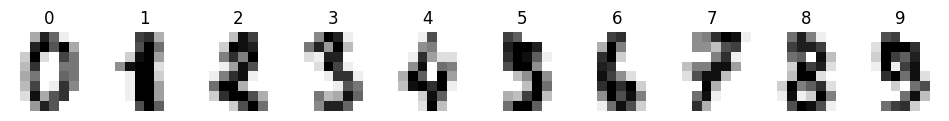

In [2]:
digits = load_digits()
print("Images :", digits.images.shape, "| vecteurs :", digits.data.shape)

fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for ax, img, label in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(label)
    ax.axis("off")
plt.show()

On garde 15 % des images pour le test, puis on standardise les pixels (moyenne 0, écart-type 1) en ajustant le scaler **uniquement sur le train** pour éviter toute fuite d'information.

In [3]:
X = np.asarray(digits.data, dtype="float32")
y = np.asarray(digits.target, dtype="int32")
X_train, X_test, y_train_int, y_test_int = train_test_split(X, y, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encodage one-hot de la cible pour la sortie softmax à 10 neurones
y_train = to_categorical(y_train_int, num_classes=10)
y_test = to_categorical(y_test_int, num_classes=10)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("Exemple one-hot :", y_train_int[0], "->", y_train[0])

X_train : (1527, 64) | X_test : (270, 64)
Exemple one-hot : 1 -> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## 2. Premier modèle Keras

Une couche cachée de 100 neurones (activation `tanh`), une sortie `softmax` à 10 classes, perte d'entropie croisée et descente de gradient stochastique (SGD, lr = 0.1).

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 7,510 (29.34 KB)

Trainable params: 7,510 (29.34 KB)

Non-trainable params: 0 (0.00 B)

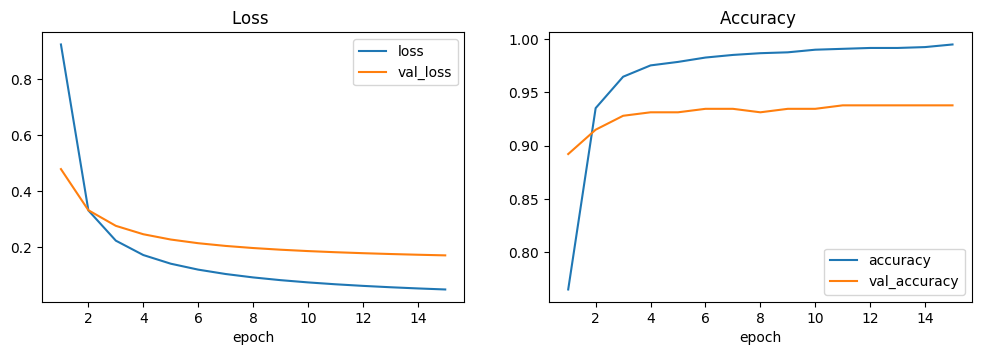

Accuracy train : 0.986 | test : 0.967


In [4]:
input_dim, hidden_dim, output_dim = X_train.shape[1], 100, 10

def plot_history(history, title=""):
    df = pd.DataFrame(history.history)
    df["epoch"] = df.index + 1
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.5))
    df.plot(x="epoch", y=["loss", "val_loss"], ax=ax0, title=f"Loss {title}")
    df.plot(x="epoch", y=["accuracy", "val_accuracy"], ax=ax1, title=f"Accuracy {title}")
    plt.show()

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(hidden_dim, activation="tanh"),
    Dense(output_dim, activation="softmax"),
])
model.compile(loss="categorical_crossentropy",
              optimizer=optimizers.SGD(learning_rate=0.1),
              metrics=["accuracy"])
model.summary()

history = model.fit(X_train, y_train, validation_split=0.2, epochs=15, verbose=0)
plot_history(history)

train_acc = model.evaluate(X_train, y_train, verbose=0)[1]
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"Accuracy train : {train_acc:.3f} | test : {test_acc:.3f}")

## 3. Impact du taux d'apprentissage et de l'optimiseur

On compare trois taux d'apprentissage pour SGD, puis on remplace SGD par **Adam** avec deux couches cachées ReLU.

lr = 0.1    -> val_accuracy finale : 0.941


lr = 0.01   -> val_accuracy finale : 0.922


lr = 0.001  -> val_accuracy finale : 0.621


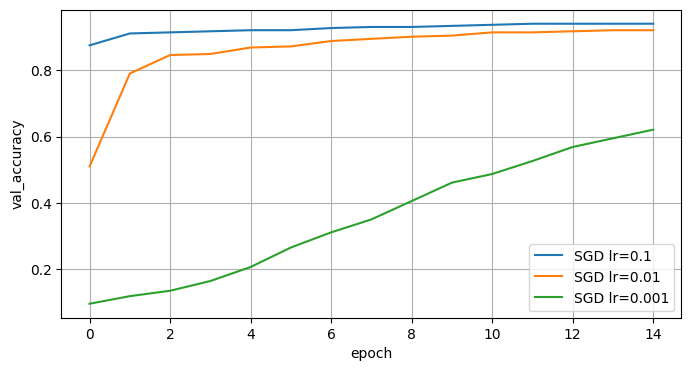

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for lr in [0.1, 0.01, 0.001]:
    m = Sequential([Input(shape=(input_dim,)),
                    Dense(hidden_dim, activation="tanh"),
                    Dense(output_dim, activation="softmax")])
    m.compile(loss="categorical_crossentropy",
              optimizer=optimizers.SGD(learning_rate=lr), metrics=["accuracy"])
    h = m.fit(X_train, y_train, validation_split=0.2, epochs=15, verbose=0)
    ax.plot(h.history["val_accuracy"], label=f"SGD lr={lr}")
    print(f"lr = {lr:<6} -> val_accuracy finale : {h.history['val_accuracy'][-1]:.3f}")
ax.set_xlabel("epoch"); ax.set_ylabel("val_accuracy"); ax.legend(); ax.grid(True)
plt.show()

Un taux d'apprentissage trop faible ralentit fortement la convergence : avec lr = 0.001, le modèle est encore loin de son optimum après 15 epochs.

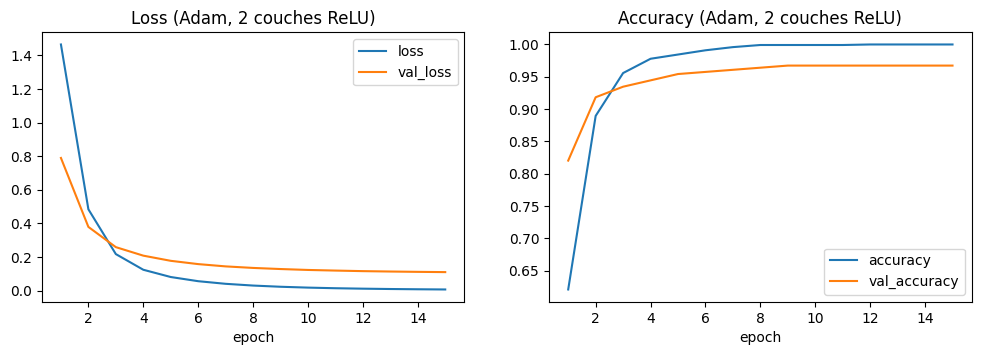

Accuracy test (Adam) : 0.963


In [6]:
model_adam = Sequential([
    Input(shape=(input_dim,)),
    Dense(hidden_dim, activation="relu"),
    Dense(hidden_dim, activation="relu"),
    Dense(output_dim, activation="softmax"),
])
model_adam.compile(loss="categorical_crossentropy",
                   optimizer=optimizers.Adam(), metrics=["accuracy"])
history_adam = model_adam.fit(X_train, y_train, validation_split=0.2, epochs=15, verbose=0)
plot_history(history_adam, "(Adam, 2 couches ReLU)")

# Forward pass sur le jeu de test
y_pred = np.argmax(model_adam.predict(X_test, verbose=0), axis=1)
print(f"Accuracy test (Adam) : {np.mean(y_pred == y_test_int):.3f}")

## 4. Impact de l'initialisation des poids

On entraîne le même réseau avec des initialisations volontairement mauvaises (poids très petits, très grands ou nuls) et trois optimiseurs.

     small + sgd      -> val_accuracy finale : 0.922


     large + sgd      -> val_accuracy finale : 0.896


very_large + sgd      -> val_accuracy finale : 0.904


     zeros + sgd      -> val_accuracy finale : 0.067


     zeros + momentum -> val_accuracy finale : 0.067


     zeros + adam     -> val_accuracy finale : 0.067


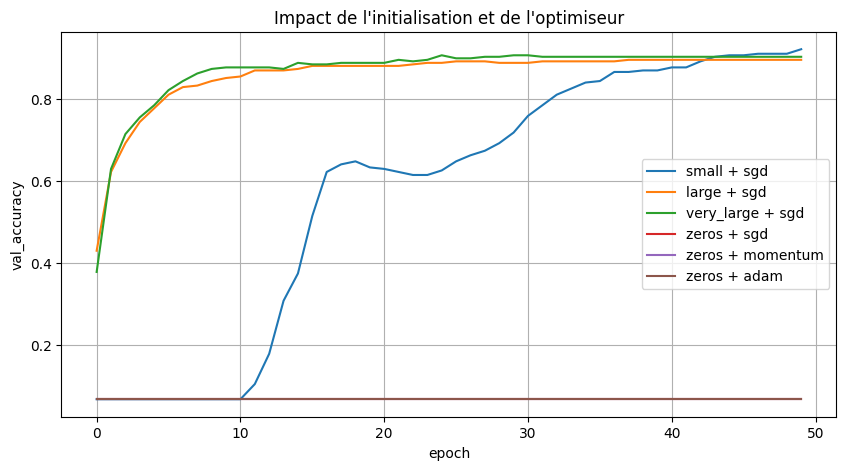

In [7]:
def train_model(init_type, optimizer_type, epochs=50):
    inits = {
        "small": initializers.RandomNormal(stddev=1e-3),
        "large": initializers.RandomNormal(stddev=1.0),
        "very_large": initializers.RandomNormal(stddev=10.0),
        "zeros": initializers.Zeros(),
    }
    opts = {
        "sgd": optimizers.SGD(learning_rate=0.01),
        "momentum": optimizers.SGD(learning_rate=0.01, momentum=0.9),
        "adam": optimizers.Adam(learning_rate=0.001),
    }
    m = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_dim, activation="relu", kernel_initializer=inits[init_type]),
        Dense(output_dim, activation="softmax", kernel_initializer=inits[init_type]),
    ])
    m.compile(optimizer=opts[optimizer_type], loss="categorical_crossentropy", metrics=["accuracy"])
    return m.fit(X_train, y_train, validation_data=(X_test, y_test),
                 epochs=epochs, batch_size=32, verbose=0)

configs = [("small", "sgd"), ("large", "sgd"), ("very_large", "sgd"),
           ("zeros", "sgd"), ("zeros", "momentum"), ("zeros", "adam")]

plt.figure(figsize=(10, 5))
for init_type, opt in configs:
    hist = train_model(init_type, opt)
    plt.plot(hist.history["val_accuracy"], label=f"{init_type} + {opt}")
    print(f"{init_type:>10} + {opt:<8} -> val_accuracy finale : {hist.history['val_accuracy'][-1]:.3f}")
plt.xlabel("epoch"); plt.ylabel("val_accuracy")
plt.title("Impact de l'initialisation et de l'optimiseur")
plt.legend(); plt.grid(True)
plt.show()

- **Poids tous nuls** : quel que soit l'optimiseur, le réseau reste bloqué à ~7 % (hasard = 10 %). Tous les neurones cachés reçoivent le même gradient et restent identiques : la symétrie n'est jamais brisée, et avec ReLU le gradient est même nul. Un meilleur optimiseur ne corrige pas une initialisation dégénérée.
- **Poids trop grands** (σ = 1 ou 10) : les activations explosent, l'entraînement est instable et plafonne autour de 90 %.
- **Poids petits** (σ = 1e-3) : le réseau apprend, mais plus lentement qu'avec l'initialisation par défaut de Keras (Glorot), conçue pour conserver la variance des activations d'une couche à l'autre.

## 5. Callbacks Keras

### a. EarlyStopping
Arrête l'entraînement quand la perte de validation ne s'améliore plus pendant 5 epochs et restaure les meilleurs poids : on évite le sur-apprentissage et les epochs inutiles.

Entraînement arrêté après 33 epochs sur 50


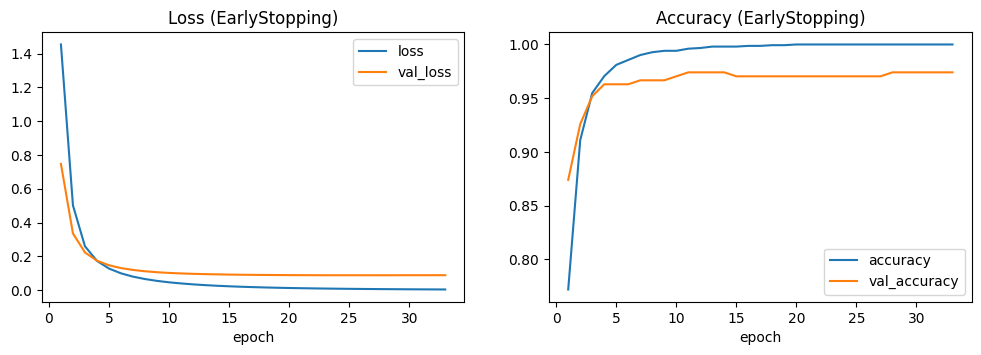

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

def build_mlp():
    m = Sequential([
        Input(shape=(input_dim,)),
        Dense(100, activation="relu", kernel_initializer=initializers.RandomNormal(stddev=0.01)),
        Dense(10, activation="softmax"),
    ])
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

model = build_mlp()
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=50, batch_size=32, callbacks=[early_stopping], verbose=0)
print(f"Entraînement arrêté après {len(history.history['loss'])} epochs sur 50")
plot_history(history, "(EarlyStopping)")

### b. ModelCheckpoint
Sauvegarde automatiquement le modèle à chaque amélioration de la perte de validation : on conserve toujours la meilleure version, même si l'entraînement se dégrade ensuite ou est interrompu.

In [9]:
model = build_mlp()
checkpoint = ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=50, batch_size=32, callbacks=[checkpoint], verbose=0)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
best_model = tf.keras.models.load_model("best_model.keras")
print(f"Meilleure epoch : {best_epoch} | accuracy test du modèle sauvegardé : "
      f"{best_model.evaluate(X_test, y_test, verbose=0)[1]:.3f}")

Meilleure epoch : 35 | accuracy test du modèle sauvegardé : 0.970


### c. TensorBoard
Enregistre les métriques, le graphe du réseau et les histogrammes des poids à chaque epoch. On visualise ensuite les logs avec `tensorboard --logdir logs` pour suivre la convergence et repérer un sur-apprentissage.

In [10]:
import datetime

log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model = build_mlp()
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32,
          callbacks=[TensorBoard(log_dir=log_dir, histogram_freq=1)], verbose=0)
print("Logs TensorBoard écrits dans", log_dir)

Logs TensorBoard écrits dans logs/20260930-164000


## 6. Comparaison avec `MLPClassifier` (scikit-learn)

Convergence après 143 itérations | accuracy test : 0.985


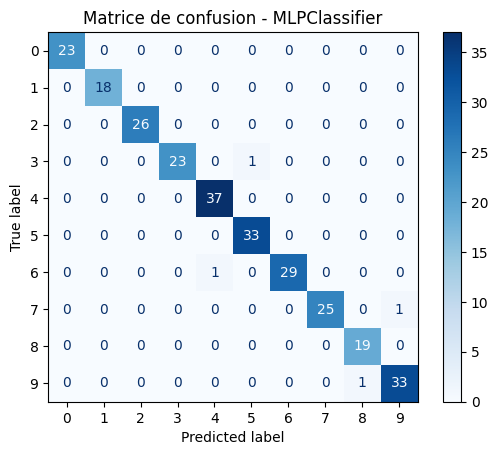

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

mlp = MLPClassifier(hidden_layer_sizes=(100,), activation="relu", solver="adam",
                    max_iter=500, random_state=42)
mlp.fit(X_train, y_train_int)
y_pred = mlp.predict(X_test)

print(f"Convergence après {mlp.n_iter_} itérations | accuracy test : {accuracy_score(y_test_int, y_pred):.3f}")
ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred, cmap="Blues")
plt.title("Matrice de confusion - MLPClassifier")
plt.show()

`MLPClassifier` est très simple à utiliser et suffisant pour des problèmes tabulaires de petite taille comme celui-ci. En revanche, il ne propose que des couches denses, ne tourne pas sur GPU et offre peu de contrôle (callbacks, couches convolutives ou récurrentes, pertes personnalisées). Keras reste l'outil adapté aux modèles profonds et aux données d'images, de texte ou de séries temporelles.

## Conclusion

| Modèle | Accuracy test |
|---|---|
| Keras — 1 couche `tanh`, SGD lr = 0.1 | 96,7 % |
| Keras — 2 couches ReLU, Adam | 96,3 % |
| Keras — ReLU + Adam + ModelCheckpoint | 97,0 % |
| scikit-learn `MLPClassifier` | 98,5 % |

Sur un petit jeu de données tabulaire, un MLP simple dépasse 96 % d'accuracy. Les choix d'entraînement (taux d'apprentissage, initialisation, early stopping) pèsent davantage que la profondeur du réseau.